# K-Nearest Neighbors (KNN) Model and Performance Comparison

This notebook is scoped to Member 4 responsibilities:
- Data preprocessing needed for KNN
- KNN model training and K-value tuning
- KNN evaluation (Accuracy, Precision, Recall, F1-score, Confusion Matrix)
- Final comparison table/plots that combine your KNN metrics with results provided by other team members

## 1. Import Required Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
    )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Load Dataset

Expected file name: `WA_Fn-UseC_-Telco-Customer-Churn.csv`

Place the dataset in one of these locations:
- `./data/WA_Fn-UseC_-Telco-Customer-Churn.csv`
- `./WA_Fn-UseC_-Telco-Customer-Churn.csv`

In [14]:
base_dir = Path.cwd()
project_dir = base_dir.parent

candidate_paths = [
    base_dir / 'dataset/Dataset/synthetic_customer_churn_100k.csv',
    project_dir / 'dataset/Dataset/synthetic_customer_churn_100k.csv',
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(
        'Dataset not found. Place a CSV in data/, dataset/, or project root.'
    )

df = pd.read_csv(dataset_path)
print(f'Loaded dataset from: {dataset_path}')
print(f'Shape: {df.shape}')
df.head()

Loaded dataset from: d:\Projects\ML Assingment\Customer-Churn-Prediction-System\dataset\Dataset\synthetic_customer_churn_100k.csv
Shape: (100000, 9)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


## 3. Initial Data Exploration

In [15]:
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(10))

candidate_target_cols = ['Churn', 'churn', 'Exited', 'exit', 'is_churn']
target_col = next((col for col in candidate_target_cols if col in df.columns), None)
if target_col is None:
    raise ValueError(
        f'Target column not found. Expected one of: {candidate_target_cols}'
    )

print(f'Using target column: {target_col}')
df[target_col].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


None

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

Using target column: Churn


Churn
No     66856
Yes    33144
Name: count, dtype: int64

## 4. Data Cleaning & Preprocessing

- Drops `customerID` (identifier only)
- Converts `TotalCharges` to numeric
- Handles missing values with imputers
- Encodes categorical variables
- Applies scaling for numeric features (important for KNN and Logistic Regression)

In [16]:
work_df = df.copy()

if 'customerID' in work_df.columns:
    work_df = work_df.drop(columns=['customerID'])

if 'CustomerID' in work_df.columns:
    work_df = work_df.drop(columns=['CustomerID'])

if 'TotalCharges' in work_df.columns:
    work_df['TotalCharges'] = pd.to_numeric(work_df['TotalCharges'], errors='coerce')

target_series = work_df[target_col]
if pd.api.types.is_string_dtype(target_series) or target_series.dtype == 'object':
    normalized_target = target_series.astype(str).str.strip().str.lower()
    target_map = {'yes': 1, 'no': 0, 'true': 1, 'false': 0, '1': 1, '0': 0}
    work_df[target_col] = normalized_target.map(target_map)

if work_df[target_col].isna().any():
    work_df = work_df.dropna(subset=[target_col])

work_df[target_col] = work_df[target_col].astype(int)

X = work_df.drop(columns=[target_col])
y = work_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool', 'string']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Numeric columns: {len(numeric_features)}, Categorical columns: {len(categorical_features)}')

Train shape: (80000, 7), Test shape: (20000, 7)
Numeric columns: 4, Categorical columns: 3


## 5. Correlation Heatmap (Numeric Features)

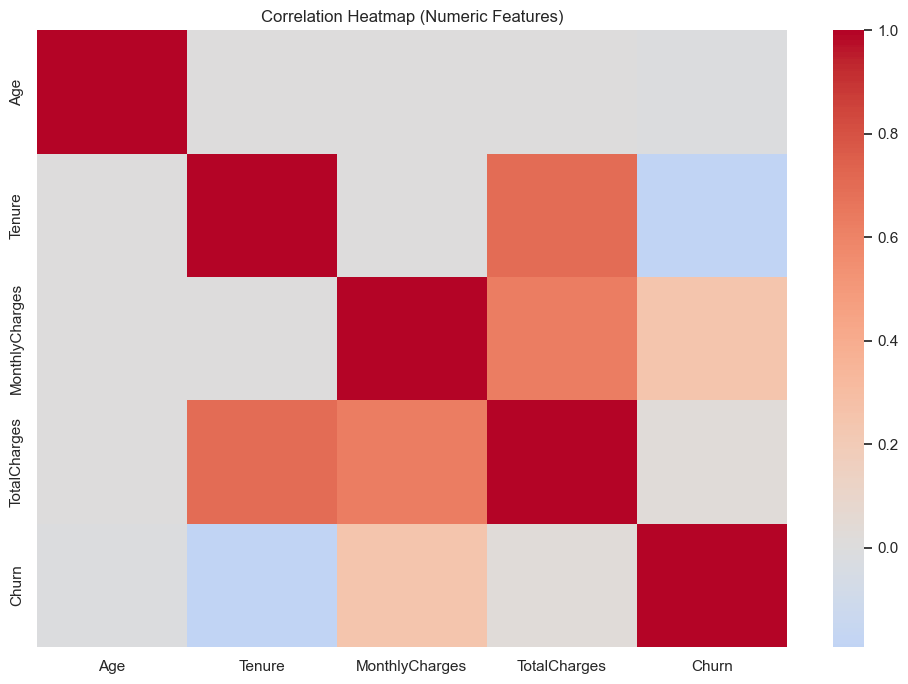

In [17]:
numeric_cols_for_corr = work_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 7))
sns.heatmap(work_df[numeric_cols_for_corr].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

## 6. Train and Evaluate KNN

In [18]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    }

    return pipeline, y_pred, metrics

knn_predictions = {}
knn_result_row = None

## 7. KNN Tuning (Select Best K)

In [19]:
k_values = [3, 5, 7, 9, 11, 13, 15]
knn_tuning_results = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    _, knn_pred, knn_metrics = evaluate_model(
        f'KNN (k={k})', knn_model, X_train, X_test, y_train, y_test
    )
    knn_tuning_results.append(knn_metrics)

knn_results_df = pd.DataFrame(knn_tuning_results).sort_values(by='F1-Score', ascending=False)
best_knn_row = knn_results_df.iloc[0]
best_k = int(best_knn_row['Model'].split('=')[1].replace(')', ''))

display(knn_results_df)
print(f'Best K selected based on F1-Score: {best_k}')

,Model,Accuracy,Precision,Recall,F1-Score
6,KNN (k=15),0.73495,0.628284,0.490572,0.550953
5,KNN (k=13),0.73340,0.623736,0.493136,0.550800
3,KNN (k=9),0.72530,0.603615,0.498718,0.546175
4,KNN (k=11),0.72740,0.610433,0.490723,0.544071
2,KNN (k=7),0.71635,0.585327,0.494645,0.536179
1,KNN (k=5),0.70725,0.566086,0.500075,0.531037
0,KNN (k=3),0.69350,0.540171,0.506110,0.522586


Best K selected based on F1-Score: 15


In [20]:
best_knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2)
best_knn_pipeline, best_knn_pred, best_knn_metrics = evaluate_model(
    f'K-Nearest Neighbors (KNN, k={best_k})',
    best_knn_model,
    X_train, X_test, y_train, y_test
)

knn_predictions['K-Nearest Neighbors (KNN)'] = best_knn_pred
knn_result_row = {
    'Model': 'K-Nearest Neighbors (KNN)',
    'Accuracy': best_knn_metrics['Accuracy'],
    'Precision': best_knn_metrics['Precision'],
    'Recall': best_knn_metrics['Recall'],
    'F1-Score': best_knn_metrics['F1-Score']
}
pd.DataFrame([knn_result_row])

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbors (KNN),0.73495,0.628284,0.490572,0.550953


## 8. Final Performance Comparison Table (Team Combined)

This table is built by reading the executed outputs from the model notebooks, so it stays in sync with reruns.

In [29]:
from pathlib import Path
import pandas as pd
import json
import re

def extract_metrics_from_notebook(notebook_path, model_name, label_map):
    notebook_path = Path(notebook_path)
    if not notebook_path.exists():
        raise FileNotFoundError(f'Notebook not found: {notebook_path}')

    with notebook_path.open('r', encoding='utf-8') as handle:
        notebook_data = json.load(handle)

    output_text = []
    for cell in notebook_data.get('cells', []):
        for output in cell.get('outputs', []):
            for key in ('text', 'text/plain'):
                value = output.get(key)
                if isinstance(value, list):
                    output_text.extend(value)
                elif isinstance(value, str):
                    output_text.append(value)

    joined_output = '\n'.join(str(item) for item in output_text)
    metrics = {'Model': model_name}

    for metric_name, label in label_map.items():
        pattern = rf'{re.escape(label)}\s*[:=]\s*([0-9]*\.?[0-9]+)'
        matches = re.findall(pattern, joined_output, flags=re.IGNORECASE)
        if not matches:
            raise ValueError(f'Could not find {metric_name} in {notebook_path.name}')
        metrics[metric_name] = float(matches[-1])

    return metrics

notebook_candidates = {
    'Logistic Regression': [
        base_dir / 'Logistic_Regression_Churn.ipynb.ipynb',
        project_dir / 'notebooks/Logistic_Regression_Churn.ipynb.ipynb',
    ],
    'Decision Tree': [
        base_dir / 'ML_Decisiontree.ipynb',
        project_dir / 'notebooks/ML_Decisiontree.ipynb',
    ],
    'Random Forest': [
        base_dir / 'random_forest_churn.ipynb',
        project_dir / 'notebooks/random_forest_churn.ipynb',
    ],
}

metric_labels = {
    'Logistic Regression': {'Accuracy': 'Accuracy', 'Precision': 'Precision', 'Recall': 'Recall', 'F1-Score': 'F1 Score'},
    'Decision Tree': {'Accuracy': 'Accuracy', 'Precision': 'Precision', 'Recall': 'Recall', 'F1-Score': 'F1-Score'},
    'Random Forest': {'Accuracy': 'Accuracy', 'Precision': 'Precision', 'Recall': 'Recall', 'F1-Score': 'F1-score'},
}

team_results = []
for model_name, candidates in notebook_candidates.items():
    notebook_path = next((path for path in candidates if path.exists()), None)
    if notebook_path is None:
        raise FileNotFoundError(f'Could not locate notebook for {model_name}')
    team_results.append(extract_metrics_from_notebook(notebook_path, model_name, metric_labels[model_name]))

team_results.append({
    'Model': 'K-Nearest Neighbors (KNN)',
    'Accuracy': best_knn_metrics['Accuracy'],
    'Precision': best_knn_metrics['Precision'],
    'Recall': best_knn_metrics['Recall'],
    'F1-Score': best_knn_metrics['F1-Score'],
})

comparison_df = pd.DataFrame(team_results).set_index('Model').sort_values(by='F1-Score', ascending=False)
comparison_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.75140,0.625600,0.623000,0.624300
Decision Tree,0.76200,0.667800,0.561000,0.609800
K-Nearest Neighbors (KNN),0.73495,0.628284,0.490572,0.550953
Logistic Regression,0.72435,0.623218,0.449896,0.522560


## 9. Visual Comparison (Bar Charts)

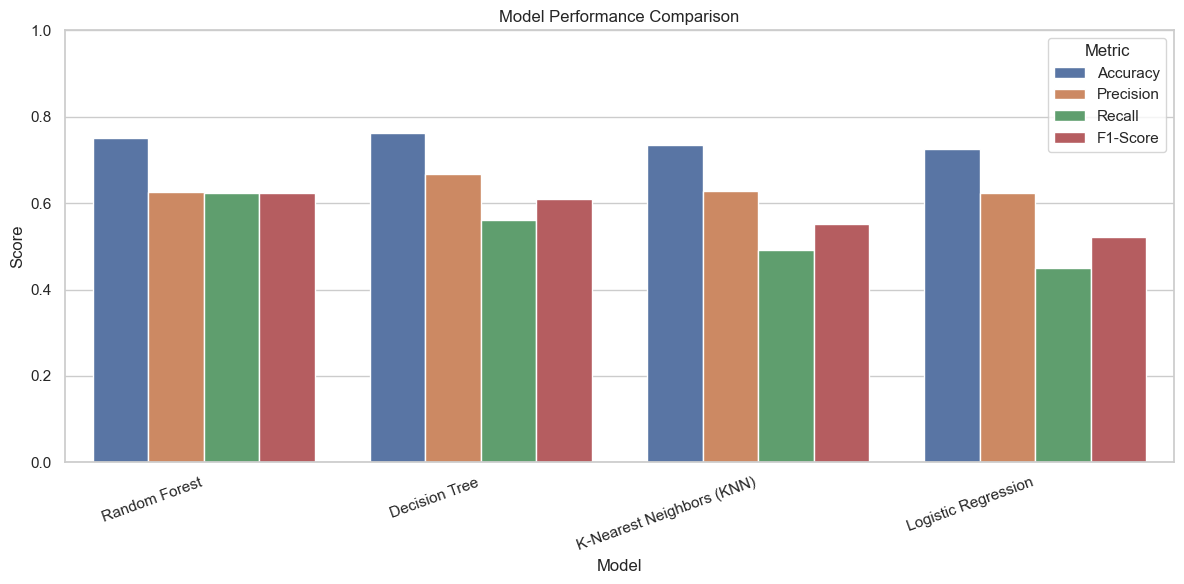

In [30]:
melted = comparison_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x='Model', y='Score', hue='Metric')
plt.title('Model Performance Comparison')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. Confusion Matrix (KNN)

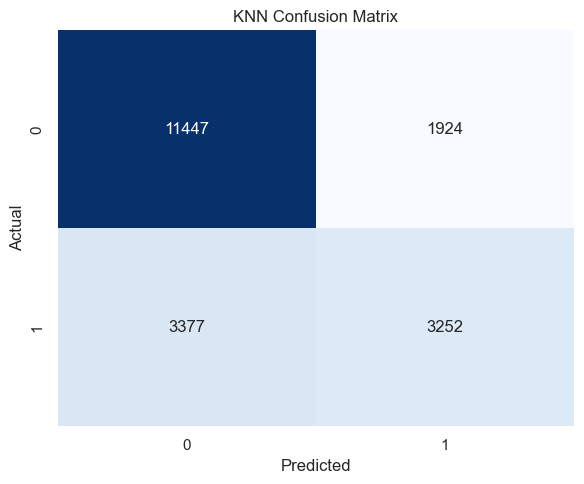

In [23]:
cm = confusion_matrix(y_test, knn_predictions['K-Nearest Neighbors (KNN)'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 11. Classification Report (KNN)

In [24]:
print(classification_report(y_test, knn_predictions['K-Nearest Neighbors (KNN)'], digits=4))

              precision    recall  f1-score   support

           0     0.7722    0.8561    0.8120     13371
           1     0.6283    0.4906    0.5510      6629

    accuracy                         0.7349     20000
   macro avg     0.7002    0.6733    0.6815     20000
weighted avg     0.7245    0.7349    0.7255     20000



## 12. Technical Summary - K-Nearest Neighbors (KNN) Model and Performance Comparison

### K-Nearest Neighbors (KNN) Model

The K-Nearest Neighbors (KNN) algorithm is a supervised machine learning classification method that classifies each record based on the majority class of its nearest neighbors in feature space. It is non-parametric and instance-based, so it does not assume a fixed data distribution and relies directly on training examples at prediction time.

In this implementation, KNN is used to predict customer churn. Euclidean distance is used to measure similarity between customers, and the final class is assigned from the majority vote among the K nearest neighbors.

Because KNN is distance-based, feature scaling is applied during preprocessing. Standardization is included in the pipeline so numeric features have comparable magnitude before distance calculation.

### Model Configuration

- Algorithm: K-Nearest Neighbors Classifier
- Distance metric: Euclidean distance (Minkowski with p=2)
- Number of neighbors (K): tuned using multiple values (for example, K = 3, 5, 7, 9, 11, 13, 15)
- Data preprocessing: imputation, one-hot encoding, and standardization

### Model Evaluation

KNN performance is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Comparative Analysis of Models

This notebook computes KNN metrics directly. Metrics for Logistic Regression, Decision Tree, and Random Forest should be filled in from other members' notebooks in the team comparison table.

### Observations

- KNN performance is sensitive to feature scaling and the selected value of K.
- Lower K values may capture local patterns but can be noisy.
- Higher K values are more stable but may smooth important class boundaries.
- In many churn datasets, ensemble models such as Random Forest may outperform KNN, but final ranking should be based on the completed team metrics table.

### Conclusion

This component delivers the KNN model implementation, tuning, and evaluation. The final model selection should be made after all four model results are merged into the shared comparison table.

### Future Improvements

- Tune additional hyperparameters (distance weighting, search strategy)
- Perform cross-validation based model selection
- Apply feature selection or dimensionality reduction
- Test class imbalance handling and threshold optimization